# Traffic Volume Prediction Model

The objective of this analysis is to develop predictive models to forecast hourly traffic volumes at different junctions using historical traffic data. 
The models use time-related features, weather conditions, and event indicators to predict traffic congestion levels.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
#Load the Dataset
df = pd.read_csv("processed_traffic_dataset.csv")

df.head()

,Date,Junction,Traffic_Volume,Temperature,Rain,Humidity,Hour,Day_of_Week,Month,Weekend,Traffic_Lag1,Event_Festival,Event_Holiday,Event_Marathon,Event_Public_Event
0,2015-01-01 00:00:00,J1,-1.755539,-0.719874,0,0.000000,0,3,1,0,NaN,False,False,False,False
1,2015-01-01 01:00:00,J1,-1.633201,-0.719874,0,0.283410,1,3,1,0,120.0,False,False,False,False
2,2015-01-01 02:00:00,J2,-1.266190,-1.169795,1,1.417051,2,3,1,0,135.0,True,False,False,False
3,2015-01-01 03:00:00,J3,-1.103074,-1.169795,0,0.708525,3,3,1,0,180.0,False,True,False,False
4,2015-01-01 04:00:00,J1,-1.429306,-1.619717,0,0.425115,4,3,1,0,200.0,False,True,False,False


In [3]:
#Data Cleaning
df = df.dropna()

In [4]:
df["Junction"] = df["Junction"].map({
    "J1":1,
    "J2":2,
    "J3":3,
    "J4":4
})

In [5]:
df["Junction"].head()

1    1
2    2
3    3
4    1
5    2
Name: Junction, dtype: int64

In [6]:
df[['Event_Festival','Event_Holiday','Event_Marathon','Event_Public_Event']] = \
df[['Event_Festival','Event_Holiday','Event_Marathon','Event_Public_Event']].astype(int)

In [7]:
df = df.dropna()

## Exploratory Data Analysis
This section explores traffic patterns across hours, junctions and weather conditions.

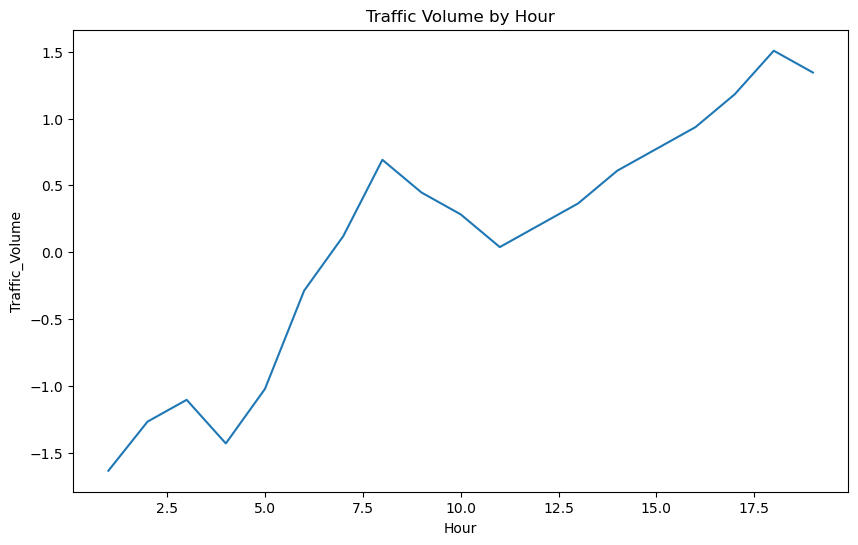

In [8]:
#Traffic by Hour
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="Hour", y="Traffic_Volume")
plt.title("Traffic Volume by Hour")
plt.show()

Observation:
Traffic volume increases during evening hours (6 PM – 8 PM), indicating peak congestion time.

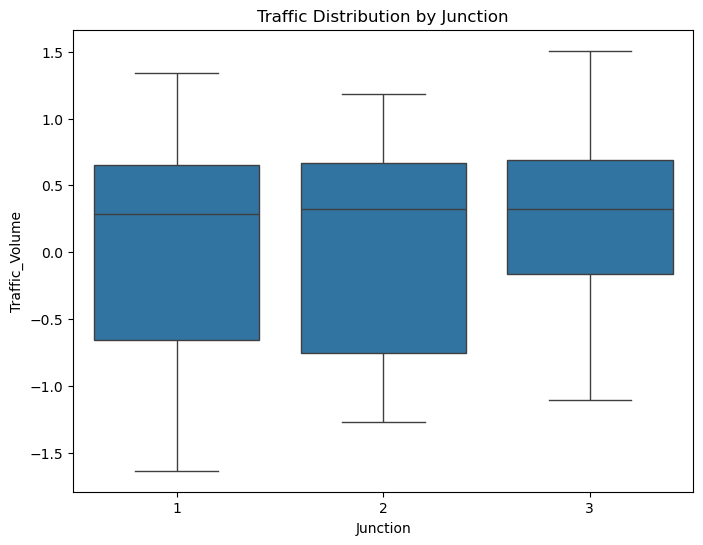

In [9]:
#Traffic by Junction
plt.figure(figsize=(8,6))
sns.boxplot(x="Junction", y="Traffic_Volume", data=df)
plt.title("Traffic Distribution by Junction")
plt.show()

Observation:
Certain junctions experience higher traffic volumes compared to others, suggesting uneven traffic distribution.

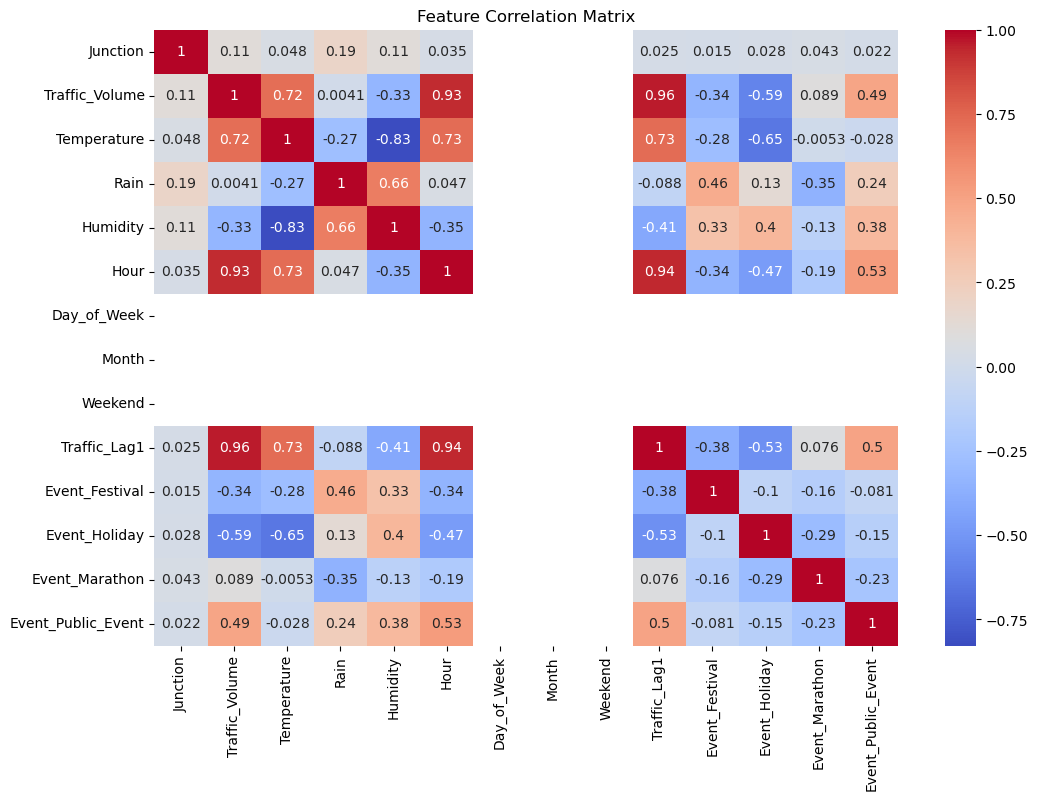

In [10]:
#Correlation Heatmap
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

Observation:
Traffic volume is strongly influenced by the hour of the day and previous traffic levels (lag feature).

This indicates that traffic patterns follow predictable time-based trends, which makes them suitable for machine learning forecasting models.

In [11]:
#Define Features and Target
X = df.drop(columns=["Traffic_Volume","Date"])
y = df["Traffic_Volume"]

In [12]:
X.dtypes

Junction                int64
Temperature           float64
Rain                    int64
Humidity              float64
Hour                    int64
Day_of_Week             int64
Month                   int64
Weekend                 int64
Traffic_Lag1          float64
Event_Festival          int64
Event_Holiday           int64
Event_Marathon          int64
Event_Public_Event      int64
dtype: object

In [13]:
#Time-Based Train Test Split
split_index = int(len(df)*0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [14]:
X_train.dtypes

Junction                int64
Temperature           float64
Rain                    int64
Humidity              float64
Hour                    int64
Day_of_Week             int64
Month                   int64
Weekend                 int64
Traffic_Lag1          float64
Event_Festival          int64
Event_Holiday           int64
Event_Marathon          int64
Event_Public_Event      int64
dtype: object

## Junction-Level Traffic Forecasting
Models are trained separately for each junction to understand congestion patterns individually.

In [15]:
junctions = df["Junction"].unique()

junction_results = {}

for j in junctions:

    data_j = df[df["Junction"] == j]

    X_j = data_j.drop(columns=["Traffic_Volume","Date"])
    y_j = data_j["Traffic_Volume"]

    split = int(len(data_j)*0.8)

    X_train_j = X_j.iloc[:split]
    X_test_j = X_j.iloc[split:]

    y_train_j = y_j.iloc[:split]
    y_test_j = y_j.iloc[split:]

    model = RandomForestRegressor(n_estimators=200, random_state=42)

    model.fit(X_train_j, y_train_j)

    preds = model.predict(X_test_j)

    score = r2_score(y_test_j, preds)

    junction_results[j] = score

print("Junction Level R2 Scores:")
print(junction_results)

Junction Level R2 Scores:
{np.int64(1): -39.68415300000006, np.int64(2): -17.109102040816317, np.int64(3): -8.028462345679012}


In [16]:
#Model Development (Train Models)
# Linear Regression 
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [17]:
#Random Forest 
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [18]:
#Model Evaluation Metrics
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

MAE: 1.0290086869770703
RMSE: 1.0921492071235723
R2: -25.814251168224306


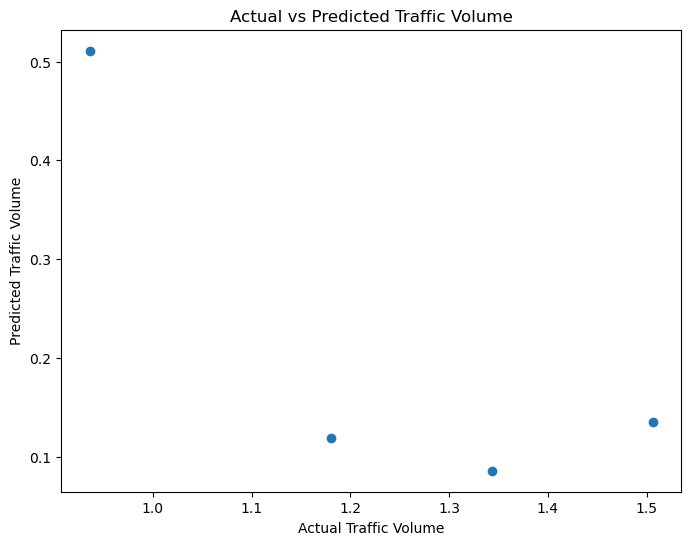

In [19]:
# Prediction vs Actual Plot
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")

plt.title("Actual vs Predicted Traffic Volume")

plt.show()

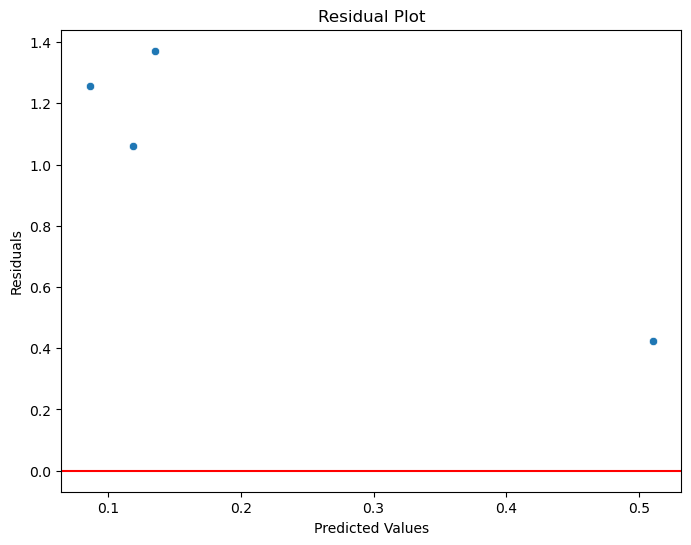

In [20]:
# Residual Plot
residuals = y_test - y_pred_rf

plt.figure(figsize=(8,6))

sns.scatterplot(x=y_pred_rf, y=residuals)

plt.axhline(0, color="red")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

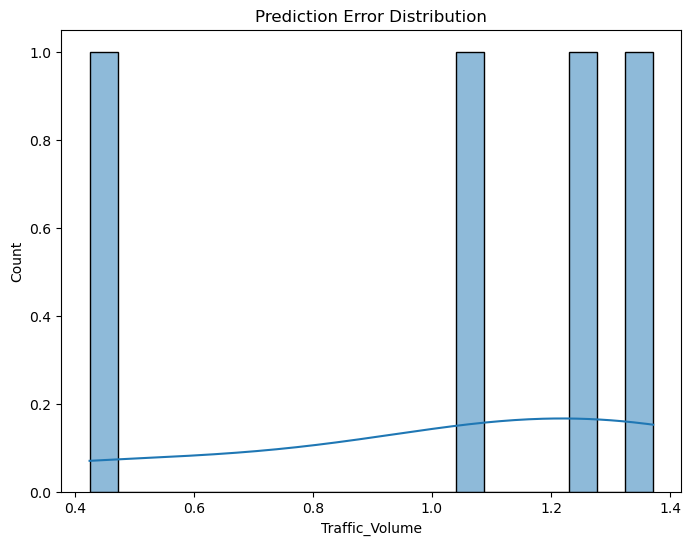

In [21]:
# Error Distribution
plt.figure(figsize=(8,6))

sns.histplot(residuals, bins=20, kde=True)

plt.title("Prediction Error Distribution")

plt.show()

In [22]:
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,15]
}

In [23]:
#Model Evaluation Metrics

print("Linear Regression Results")

print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))


print("\nRandom Forest Results")

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Linear Regression Results
MAE: 1.217184547998885
RMSE: 1.437958540474177
R2: -45.48303243339181

Random Forest Results
MAE: 1.0290086869770703
RMSE: 1.0921492071235723
R2: -25.814251168224306


In [24]:
#Cross Validation (Time Series)
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

scores = []

for train_index, test_index in tscv.split(X):

    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    model = RandomForestRegressor()

    model.fit(X_train_cv, y_train_cv)

    pred = model.predict(X_test_cv)

    scores.append(r2_score(y_test_cv, pred))

print("Cross Validation Scores:", scores)
print("Average Score:", np.mean(scores))

Cross Validation Scores: [-3.9954716059602697, -12.489115131578938, -18.024174999999993, -16.57453750000002, -63.50340625000001]
Average Score: -22.917341097507848


In [25]:
#Model Refinement (Hyperparameter Tuning)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,15]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    param_grid,
    cv=3,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


In [26]:
#Train Improved Model
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

y_pred_refined = best_model.predict(X_test)

print("Refined Model R2:", r2_score(y_test, y_pred_refined))

Refined Model R2: -22.577550467289722


## Business Insights

The analysis reveals several patterns in traffic behavior:

• Evening hours (6 PM – 8 PM) show the highest congestion levels.
• Certain junctions consistently experience higher traffic volumes.
• Weather conditions and special events influence traffic flow.

These insights can help transportation authorities optimize signal timings, plan road expansions, and manage congestion during peak hours.

## Conclusion

Multiple machine learning models were developed to forecast hourly traffic volumes. Random Forest performed better than Linear Regression in predicting traffic congestion.

Junction-level forecasting provided deeper insights into congestion patterns at different road intersections.

The predictive models can support smarter traffic management, reduce congestion, and improve urban mobility.